# Começando - RocketPy no Colab


Começamos configurando nosso ambiente. Para executar este notebook, vamos precisar:

- RocketPy
- Arquivos de dados (vamos baixar os dados do RocketPy do GitHub)

Portanto, vamos executar as seguintes linhas de código:

In [ ]:
!pip install rocketpy
!curl -o NACA0012-radians.txt https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt
!curl -o Cesaroni_M1670.eng https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/motors/cesaroni/Cesaroni_M1670.eng
!curl -o powerOffDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/calisto/powerOffDragCurve.csv
!curl -o powerOnDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/calisto/powerOnDragCurve.csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.5/372.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.7 MB/s eta 0:00:00
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=10d82814988bae89910ac38e6dc2cb2c246f5a563d615f7c4d806632344873f4
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1052  100  1052    0     0   6451      0 --:--:-- --:--:-- --:--:--  6493
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dlo

Agora podemos começar!

Aqui faremos uma simulação simplificada da trajetória de um foguete para você iniciar. Vamos começar importando o módulo rocketpy.


In [ ]:
from rocketpy import Environment, Flight, Rocket, SolidMotor

Recomenda-se executar a linha a seguir para que os gráficos do matplotlib exibidos adiante fiquem interativos e com maior qualidade.


In [ ]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

## Configurando uma Simulação


### Criando um Ambiente para o Spaceport America



A classe `Environment` é usada para definir a atmosfera, os ventos e os modelos de gravidade.

Você pode encontrar mais informações sobre a classe `Environment` na [Documentação de Uso da Classe Environment](https://docs.rocketpy.org/en/latest/notebooks/environment/environment_class_usage.html).

In [ ]:
env = Environment(latitude=32.990254, longitude=-106.974998, elevation=1400)

Para obter dados meteorológicos da previsão GFS, disponível online, executamos as linhas a seguir.

Primeiro, definimos a data de amanhã.


In [ ]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hora em UTC

Em seguida, informamos ao `env` para usar uma previsão GFS a fim de obter as condições atmosféricas para o voo.

Não se preocupe com o aviso: ele apenas indica que nem todas as variáveis, como velocidade do vento ou temperatura atmosférica, estão disponíveis em todas as altitudes fornecidas pela previsão.


In [ ]:
env.set_atmospheric_model(type="Forecast", file="GFS")

Podemos ver como estará o tempo chamando o método info!



Gravity Details

Acceleration of gravity at surface level:    9.7911 m/s²
Acceleration of gravity at  79.613 km (ASL): 9.5545 m/s²


Launch Site Details

Launch Date: 2025-09-19 12:00:00 UTC
Launch Site Latitude: 32.99025°
Launch Site Longitude: -106.97500°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 315468.64 W    3651938.65 N
Launch Site UTM zone: 13S
Launch Site Surface Elevation: 1471.5 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 79.613 km
Forecast Time Period: from 2025-09-18 06:00:00 to 2025-10-04 06:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From -90.0° to 90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 0.53 m/s
Surface Wind Direction: 351.11°
Surface Wind Heading: 171.11°
Surface Pressure: 854.77 hPa
Surface Temperature: 292.81 K
Surface Air Density: 1.017 kg/m³
Surface Speed of Sound: 343.03 m/s


Earth Model Details

Earth Radius at Launch

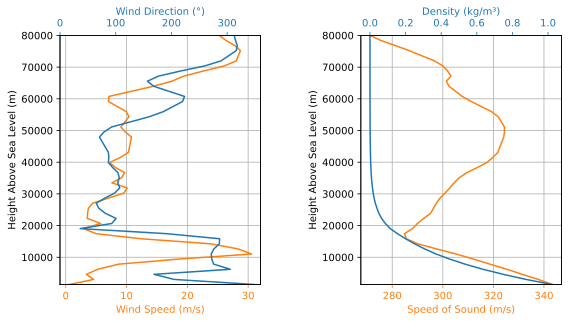

In [ ]:
env.info()

### Criando um Motor

Neste caso, é usado um motor de foguete sólido. Para criar um motor, utiliza-se a classe SolidMotor e fornecem-se os argumentos necessários.

A classe SolidMotor exige que o usuário tenha uma curva de empuxo pronta. Isso pode vir de um arquivo .eng para um motor comercial, como abaixo, ou de um arquivo .csv proveniente de uma medição de teste estático.

Além da curva de empuxo, também devem ser informados outros parâmetros, como propriedades dos grãos e dimensões do bocal.

Consulte a [Documentação de Uso da Classe SolidMotor](https://docs.rocketpy.org/en/latest/user/motors/solidmotor.html) para mais informações.


In [ ]:
Pro75M1670 = SolidMotor(
    thrust_source="Cesaroni_M1670.eng",
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=33 / 1000,
    grain_number=5,
    grain_density=1815,
    grain_outer_radius=33 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5 / 1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.9,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

**Preste atenção especial aos parâmetros relacionados à *posição*:**
Mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)


Para ver como é a nossa curva de empuxo, juntamente com outras propriedades importantes, chamamos o método info novamente. Você pode tentar o método all_info se quiser mais informações de uma só vez!


Nozzle Details
Nozzle Radius: 0.033 m
Nozzle Throat Radius: 0.011 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.033 m
Grain Inner Radius: 0.015 m
Grain Height: 0.12 m
Grain Volume: 0.000 m3
Grain Mass: 0.591 kg

Motor Details
Total Burning Time: 3.9 s
Total Propellant Mass: 2.956 kg
Structural Mass Ratio: 0.380
Average Propellant Exhaust Velocity: 2038.745 m/s
Average Thrust: 1545.218 N
Maximum Thrust: 2200.0 N at 0.15 s after ignition.
Total Impulse: 6026.350 Ns



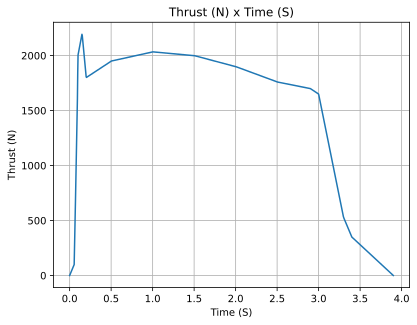

In [ ]:
Pro75M1670.info()

### Criando um Foguete


Um foguete é composto por vários componentes. Ou seja, devemos ter um motor (ainda bem que já temos o Pro75M1670 pronto), algumas superfícies aerodinâmicas (nariz, aletas e cauda) e paraquedas (se não estivermos lançando um míssil).

Você pode encontrar mais informações sobre a classe `Rocket` na [Documentação de Uso da Classe Rocket](https://docs.rocketpy.org/en/latest/user/rocket.html).

Vamos começar inicializando nosso foguete, chamado Calisto, inserindo propriedades de inércia, algumas dimensões e curvas de arrasto.

**Preste atenção especial aos parâmetros relacionados à *posição*:**
Mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)



In [ ]:
calisto = Rocket(
    radius=127 / 2000,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="powerOffDragCurve.csv",
    power_on_drag="powerOnDragCurve.csv",
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)

rail_buttons = calisto.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)

Para adicionar o motor ao nosso foguete, basta informar qual motor estamos adicionando (Pro75M1670) e indicar a posição, em metros, da área de saída do bocal do motor em relação ao sistema de coordenadas previamente definido.


In [ ]:
calisto.add_motor(Pro75M1670, position=-1.255)

#### Adicionando Superfícies Aerodinâmicas


Agora definimos as superfícies aerodinâmicas. Elas são bem diretas, exigindo atenção especial apenas aos valores de posição. Aqui vai um guia rápido:

- As posições fornecidas **devem** ser relativas ao mesmo sistema de coordenadas do foguete;
- A posição do nariz (nosecone) refere-se à ponta do nariz;
- A posição das aletas refere-se ao ponto pertencente à corda de raiz que é o mais alto no sistema de coordenadas do foguete;
- A posição da cauda refere-se ao ponto pertencente à cauda que é o mais alto no sistema de coordenadas do foguete.

Veja mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)

In [ ]:
nose_cone = calisto.add_nose(length=0.55829, kind="vonKarman", position=1.278)

fin_set = calisto.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
    airfoil=("NACA0012-radians.txt", "radians"),
)

tail = calisto.add_tail(
    top_radius=0.0635, bottom_radius=0.0435, length=0.060, position=-1.194656
)

Para ver todas as informações referentes ao foguete que acabamos de definir, executamos:



Inertia Details

Rocket Mass: 14.426 kg (without motor)
Rocket Dry Mass: 16.241 kg (with unloaded motor)
Rocket Loaded Mass: 19.197 kg
Rocket Structural Mass Ratio: 0.846
Rocket Inertia (with unloaded motor) 11: 7.864 kg*m2
Rocket Inertia (with unloaded motor) 22: 7.864 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.036 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0635 m
Rocket Frontal Area: 0.012668 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.105 m
Rocket Center of Dry Mass - Nozzle Exit: 1.150 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.753 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.116 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 6.280/rad
Tail Lift Coefficient De

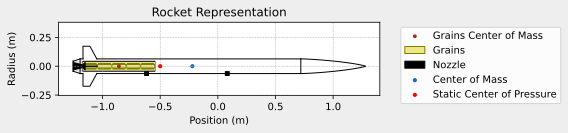


Mass Plots
----------------------------------------


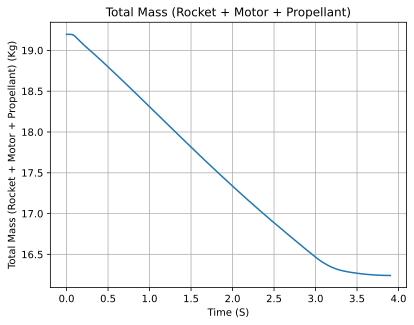

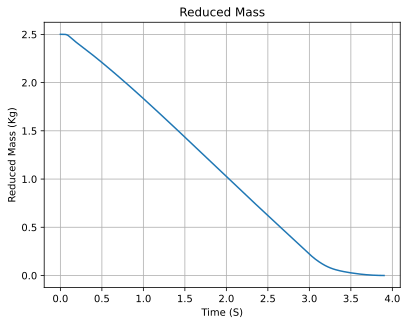


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


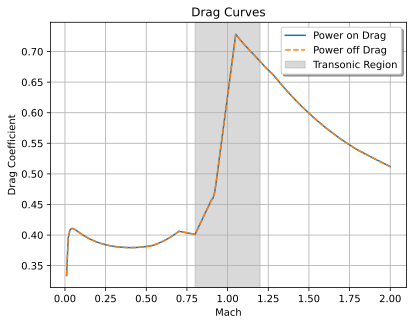


Stability Plots
--------------------


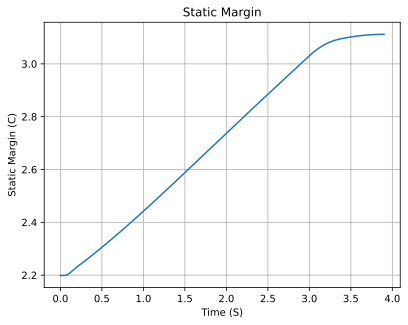

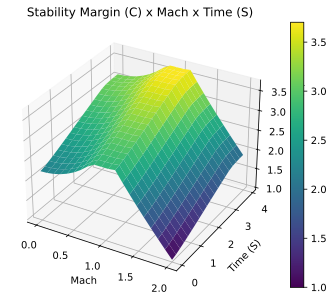


Thrust-to-Weight Plot
----------------------------------------


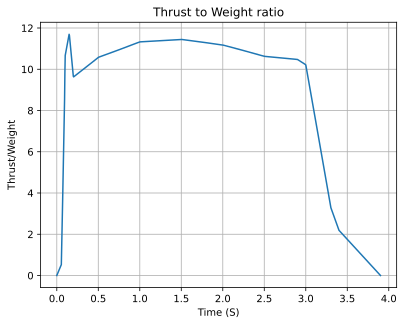

In [ ]:
calisto.all_info()

#### Adicionando Paraquedas


Finalmente, temos os paraquedas! O Calisto terá dois paraquedas, Drogue e Main. O paraquedas Drogue abrirá no apogeu, enquanto o paraquedas Main abrirá a 800 m acima do nível do solo.

Para mais detalhes, veja [Adicionando Paraquedas](https://docs.rocketpy.org/en/latest/user/rocket.html#adding-parachutes)

In [ ]:
Main = calisto.add_parachute(
    "Main",
    cd_s=10.0,
    trigger=800,
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

Drogue = calisto.add_parachute(
    "Drogue",
    cd_s=1.0,
    trigger="apogee",
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

Atenção ao executar esta última célula várias vezes! Se fizer isso, seu foguete terminará com muitos paraquedas que ativam juntos, o que pode causar problemas durante a simulação de voo. Recomendamos executar novamente todas as células que definem nosso foguete antes desta, prevenindo paraquedas antigos indesejados. Como alternativa, você pode executar as linhas a seguir para remover paraquedas.

```python
Calisto.parachutes.remove(Drogue)
Calisto.parachutes.remove(Main)
```


## Simulando um Voo

Simular uma trajetória de voo é tão simples quanto inicializar um objeto da classe Flight, fornecendo o foguete e o ambiente configurados acima como entradas. A inclinação e a orientação do trilho de lançamento também são informadas aqui.


In [ ]:
test_flight = Flight(
    rocket=calisto, environment=env, rail_length=5.2, inclination=85, heading=0
)

## Analisando os Resultados

O RocketPy oferece muitos gráficos, com certeza! Eles são divididos em seções para mantê-los organizados. Como alternativa, consulte a documentação da classe Flight para ver como obter gráficos apenas de variáveis específicas, em vez de todos de uma vez.



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 1471.47 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.199 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.52 m/s
Lateral Surface Wind Speed: -0.09 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.368 s
Rail Departure Velocity: 26.208 m/s
Rail Departure Stability Margin: 2.276 c
Rail Departure Angle of Attack: 1.136°
Rail Departure Thrust-Weight Ratio: 10.152
Rail Departure Reynolds Number: 1.871e+05


Burn out State

Burn out time: 3.900 s
Altitude at burn out: 2129.878 m (ASL) | 658.413 m (AGL)
Rocket speed at burn out: 281.117 m/s
Freestream vel

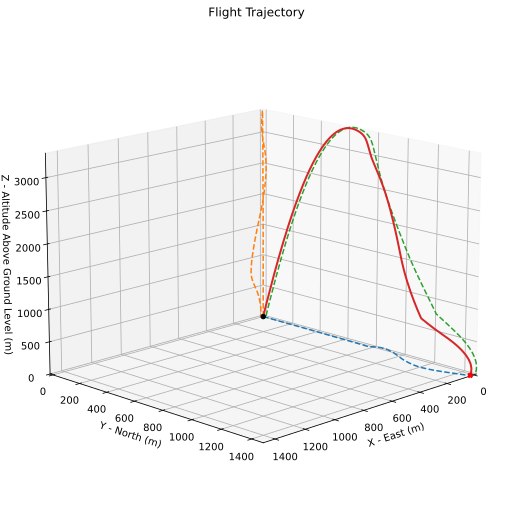



Trajectory Kinematic Plots



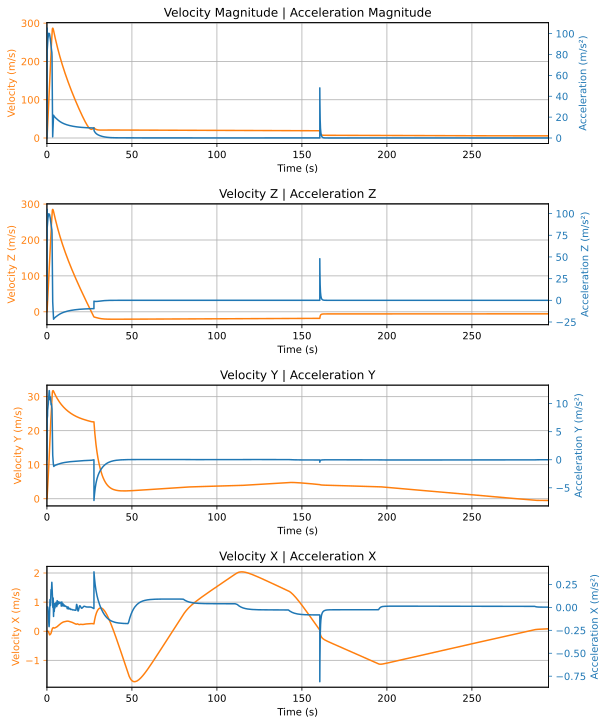



Angular Position Plots



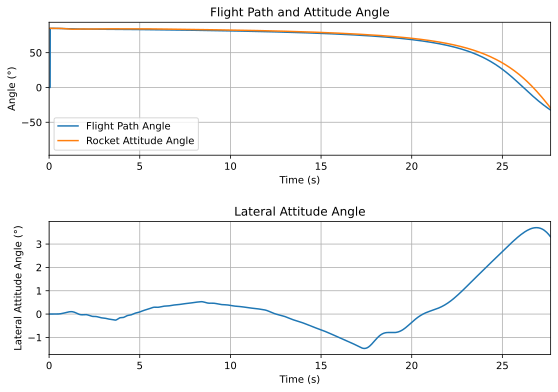



Path, Attitude and Lateral Attitude Angle plots



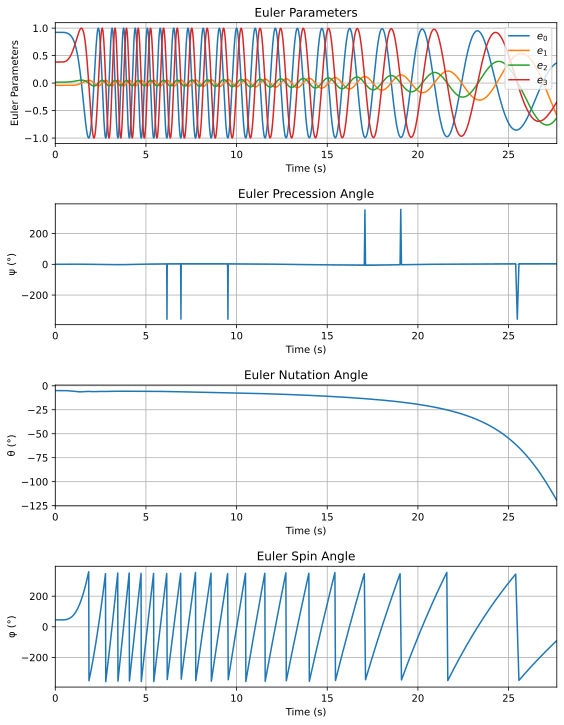



Trajectory Angular Velocity and Acceleration Plots



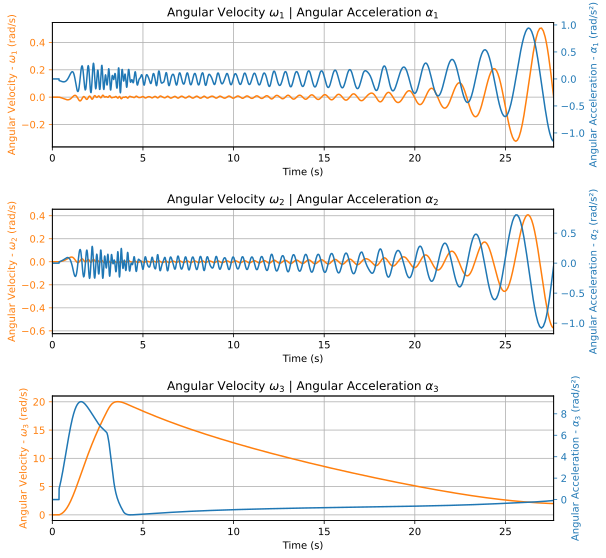



Aerodynamic Forces Plots



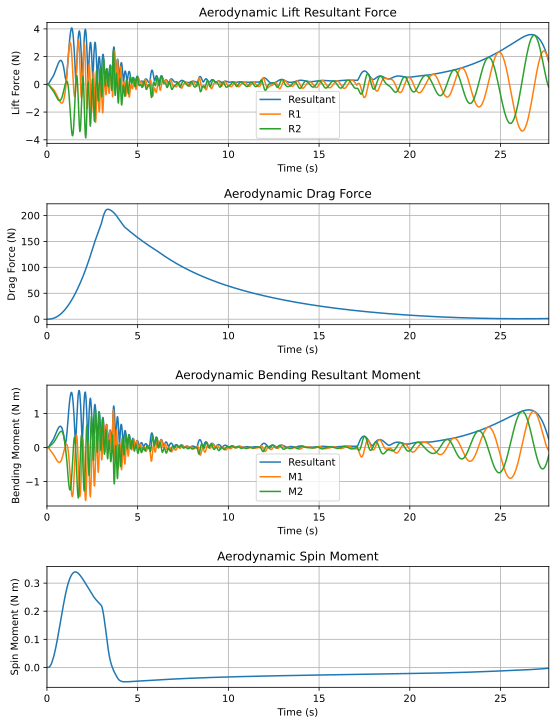



Rail Buttons Forces Plots



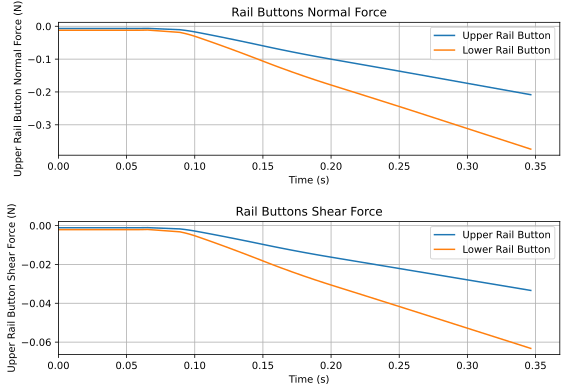



Trajectory Energy Plots



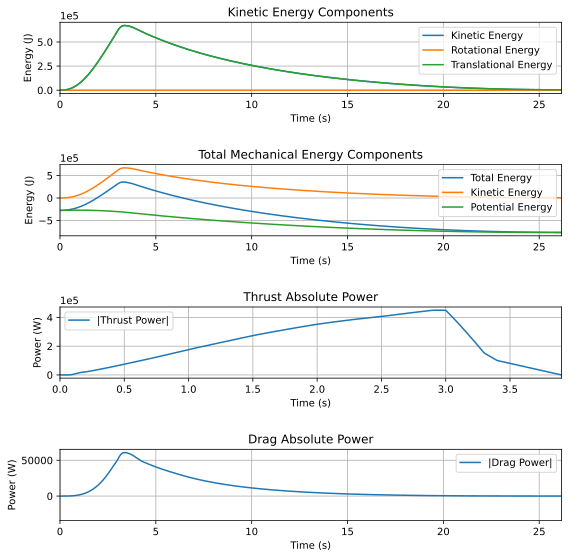



Trajectory Fluid Mechanics Plots



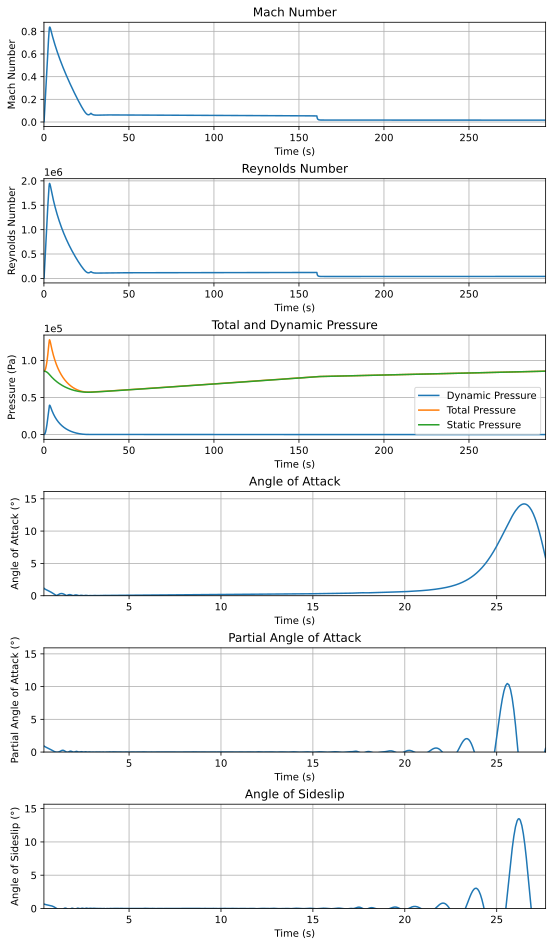



Trajectory Stability and Control Plots



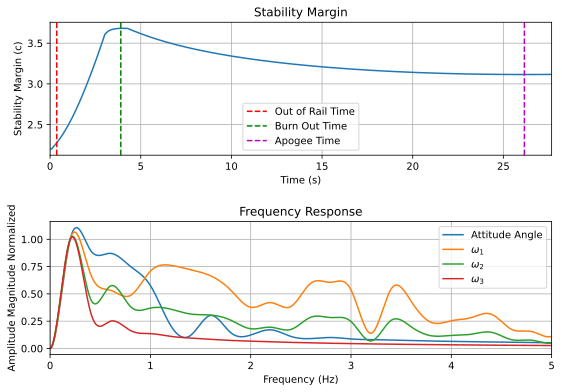



Rocket and Parachute Pressure Plots



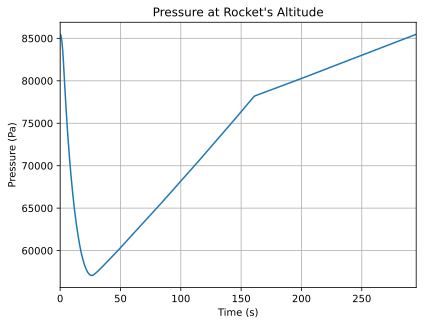


Parachute:  Main


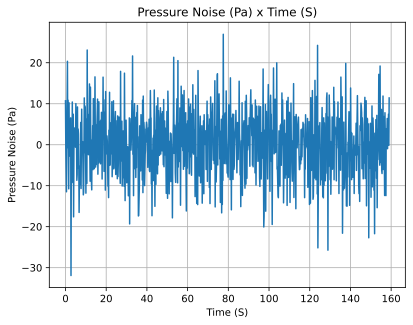

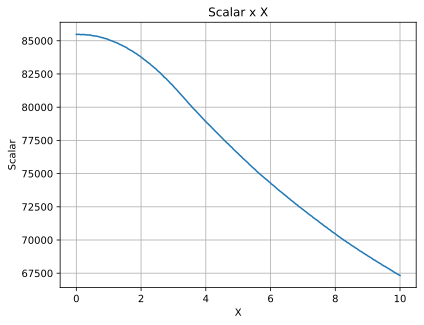

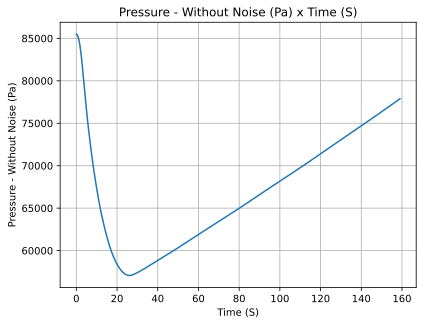


Parachute:  Drogue


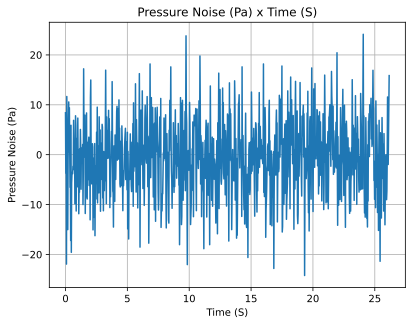

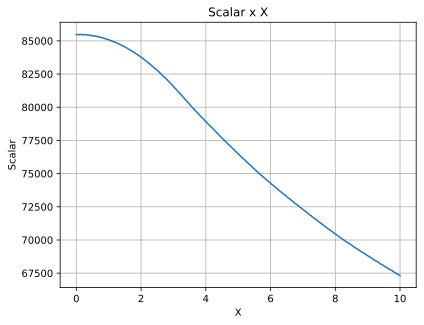

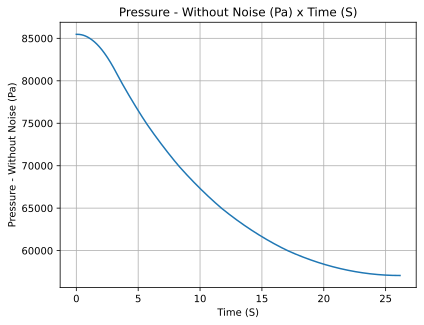

In [ ]:
test_flight.all_info()

Exporte a trajetória do voo para um arquivo .kml para que possa ser aberto no Google Earth


In [ ]:
test_flight.export_kml(
    file_name="trajectory.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  trajectory.kml  saved with success!


## Usando a Simulação para Projeto

Aqui, veremos alguns exemplos que usam o RocketPy de maneiras interessantes para nos ajudar a projetar nosso foguete.


### Apogeu em Função da Massa

Este é um clássico! Sempre precisamos saber quanto o apogeu do nosso foguete mudará quando a carga útil ficar mais pesada.


In [ ]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

### Velocidade de Saída do Trilho em Função da Massa

Vamos fazer um gráfico muito importante. A velocidade de saída do trilho é a velocidade que nosso foguete tem quando está deixando o trilho de lançamento. Isso é crucial para garantir que ele possa voar com segurança após sair do trilho. Uma regra prática comum é que a velocidade de saída do trilho do nosso foguete deve ser 4 vezes a velocidade do vento para que ele não entre em estol e se torne instável.


In [ ]:
from rocketpy.utilities import liftoff_speed_by_mass

liftoff_speed_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=10, plot=True)

### Análise de Estabilidade Dinâmica

Já se perguntou como a estabilidade estática se traduz em estabilidade dinâmica? Margens estáticas diferentes resultam em comportamentos dinâmicos distintos, o que também depende da inércia rotacional do foguete.

Vamos usar a classe auxiliar do RocketPy chamada Function para explorar como a estabilidade dinâmica do Calisto varia se mudarmos a envergadura das aletas por um determinado fator.


In [ ]:
# Classe auxiliar
import copy

from rocketpy import Function

# Preparar uma cópia do foguete
calisto2 = copy.deepcopy(calisto)

# Preparar a classe Environment
custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

# Simular diferentes margens estáticas variando a posição das aletas
simulation_results = []

for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
    # Modificar conjunto de aletas removendo o anterior e adicionando um novo
    calisto2.aerodynamic_surfaces.pop(-1)

    fin_set = calisto2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=-1.04956 * factor,
    )
    # Simular
    print(
        "Simulando foguete com margem estática de {:1.3f}->{:1.3f} c".format(
            calisto2.static_margin(0),
            calisto2.static_margin(calisto2.motor.burn_out_time),
        )
    )
    test_flight = Flight(
        rocket=calisto2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=5,
        terminate_on_apogee=True,
        verbose=True,
    )
    # Armazenar resultados
    static_margin_at_ignition = calisto2.static_margin(0)
    static_margin_at_out_of_rail = calisto2.static_margin(test_flight.out_of_rail_time)
    static_margin_at_steady_state = calisto2.static_margin(test_flight.t_final)
    simulation_results += [
        (
            test_flight.attitude_angle,
            "{:1.2f} c | {:1.2f} c | {:1.2f} c".format(
                static_margin_at_ignition,
                static_margin_at_out_of_rail,
                static_margin_at_steady_state,
            ),
        )
    ]

Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Tempo (s)",
    ylabel="Ângulo de atitude (graus)",
)

### Cálculo da Frequência Característica

Aqui analisamos a frequência característica de oscilação do nosso foguete assim que ele deixa o trilho de lançamento. Observe que, quando executamos test_flight.all_info(), um dos gráficos já mostrava o espectro de frequência do nosso voo. Aqui, no entanto, temos mais controle sobre o que estamos representando.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simular os primeiros 5 segundos de voo
flight = Flight(
    rocket=calisto,
    environment=env,
    rail_length=5.2,
    inclination=90,
    heading=0,
    max_time_step=0.01,
    max_time=5,
)

# Realizar uma análise de Fourier
Fs = 100.0
# taxa de amostragem
Ts = 1.0 / Fs
# intervalo de amostragem
t = np.arange(1, 400, Ts)  # vetor de tempo
ff = 5
# frequência do sinal
y = flight.attitude_angle(t) - np.mean(flight.attitude_angle(t))
n = len(y)  # comprimento do sinal
k = np.arange(n)
T = n / Fs
frq = k / T  # faixa de frequência de dois lados
frq = frq[range(n // 2)]  # faixa de frequência de um lado
Y = np.fft.fft(y) / n  # cálculo e normalização da FFT
Y = Y[range(n // 2)]

# Criar o gráfico
fig, ax = plt.subplots(2, 1)
ax[0].plot(t, y)
ax[0].set_xlabel("Tempo")
ax[0].set_ylabel("Sinal")
ax[0].set_xlim((0, 5))
ax[0].grid()
ax[1].plot(frq, abs(Y), "r")  # plotando o espectro
ax[1].set_xlabel("Frequência (Hz)")
ax[1].set_ylabel("|Y(frequência)|")
ax[1].set_xlim((0, 5))
ax[1].grid()
plt.subplots_adjust(hspace=0.5)
plt.show()